# Week 11 Jupyter Notebook — Clustering Part 2: DBSCAN and HAC

## Objective

This notebook applies Week 11 clustering methods to my airline delay capstone project. The goal is to compare density-based clustering and hierarchical clustering with the airline delay dataset.

For this week, I focused on:

- DBSCAN
- HAC / hierarchical agglomerative clustering
- linkage methods
- dendrograms
- cluster interpretation using `DEP_DEL15`

As with Week 10, this is unsupervised learning. I do not use `DEP_DEL15` to create the clusters. I use it after clustering to see whether the clusters have different delay rates.

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram

## 1. Load the datasets

The main data source is the Kaggle `train.csv` file from the airline delay dataset. The BTS delay data is included as supporting context if it is available.

DBSCAN and hierarchical clustering can be slow on large datasets, so this notebook uses smaller samples than the supervised learning notebooks.

In [2]:
SAMPLE_SIZE = 50000
CLUSTER_SAMPLE_SIZE = 5000
DENDROGRAM_SAMPLE_SIZE = 400
RANDOM_STATE = 42

train = pd.read_csv("data/train.csv", nrows=SAMPLE_SIZE)

try:
    delay = pd.read_csv("data/Flight_delay.csv")
    print("BTS delay file shape:", delay.shape)
except FileNotFoundError:
    print("BTS delay file not found. Continuing with train.csv only.")

print("Train shape:", train.shape)
train.head()

BTS delay file shape: (484551, 29)
Train shape: (50000, 30)


,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,7,7,0,1500-1559,3,3,26,160,American Airlines Inc.,19534,...,Chicago O'Hare International,0.00,0.0,0.0,95.0,4.25,0.237709,0.273236,0.222538,0.255479
1,4,1,0,1300-1359,4,4,63,50,SkyWest Airlines Inc.,18788,...,El Paso International,0.00,0.0,0.0,71.0,11.41,0.154651,0.121849,0.237972,0.197503
2,11,4,0,0001-0559,2,1,3,76,American Eagle Airlines Inc.,1148,...,NONE,0.00,0.0,0.0,54.0,0.45,0.117559,0.187867,0.139886,0.060327
3,3,2,0,1500-1559,7,5,14,143,Southwest Airlines Co.,7612,...,San Jose International,0.00,0.0,0.0,64.0,8.05,0.204389,0.141446,0.132868,0.202037
4,7,3,0,0800-0859,1,2,85,50,American Eagle Airlines Inc.,29376,...,Cincinnati/Northern Kentucky International,0.01,0.0,0.0,94.0,10.51,0.203263,0.193761,0.203027,0.113050


## 2. Quick EDA

The target variable is `DEP_DEL15`. It is not used for clustering, but it is useful for interpreting whether different clusters have different delay rates.

Target counts:
DEP_DEL15
0    40520
1     9480
Name: count, dtype: int64

Target percentage:
DEP_DEL15
0    81.04
1    18.96
Name: proportion, dtype: float64

Overall delay rate: 0.1896


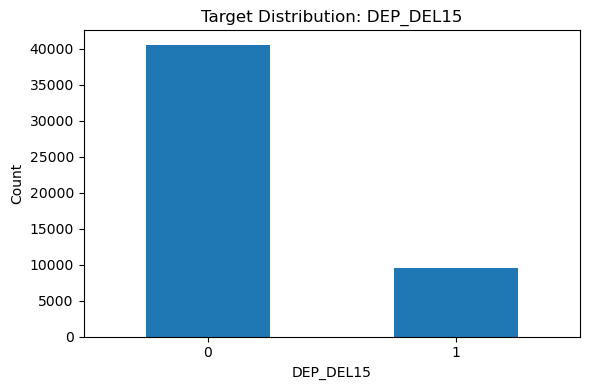

In [4]:
target = "DEP_DEL15"

print("Target counts:")
print(train[target].value_counts(dropna=False))

print("\nTarget percentage:")
print((train[target].value_counts(normalize=True, dropna=False) * 100).round(2))

overall_delay_rate = train[target].mean()
print("\nOverall delay rate:", round(overall_delay_rate, 4))

plt.figure(figsize=(6, 4))
train[target].value_counts().sort_index().plot(kind="bar")
plt.title("Target Distribution: DEP_DEL15")
plt.xlabel("DEP_DEL15")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Select clustering features

I use the same main numeric features as the earlier notebooks. These include schedule, weather, airport activity, carrier history, and historical delay variables.

The target variable is kept only for cluster interpretation after the unsupervised models are created.

In [5]:
target = "DEP_DEL15"

numeric_candidates = [
    "MONTH",
    "DAY_OF_WEEK",
    "DISTANCE_GROUP",
    "SEGMENT_NUMBER",
    "CONCURRENT_FLIGHTS",
    "NUMBER_OF_SEATS",
    "AIRPORT_FLIGHTS_MONTH",
    "AIRLINE_FLIGHTS_MONTH",
    "AIRLINE_AIRPORT_FLIGHTS_MONTH",
    "AVG_MONTHLY_PASS_AIRPORT",
    "AVG_MONTHLY_PASS_AIRLINE",
    "FLT_ATTENDANTS_PER_PASS",
    "GROUND_SERV_PER_PASS",
    "PLANE_AGE",
    "LATITUDE",
    "LONGITUDE",
    "PRCP",
    "SNOW",
    "SNWD",
    "TMAX",
    "AWND",
    "CARRIER_HISTORICAL",
    "DEP_AIRPORT_HIST",
    "DAY_HISTORICAL",
    "DEP_BLOCK_HIST"
]

features = [col for col in numeric_candidates if col in train.columns]

print("Target used for interpretation:", target)
print("Number of clustering features used:", len(features))
print(features)

Target used for interpretation: DEP_DEL15
Number of clustering features used: 25
['MONTH', 'DAY_OF_WEEK', 'DISTANCE_GROUP', 'SEGMENT_NUMBER', 'CONCURRENT_FLIGHTS', 'NUMBER_OF_SEATS', 'AIRPORT_FLIGHTS_MONTH', 'AIRLINE_FLIGHTS_MONTH', 'AIRLINE_AIRPORT_FLIGHTS_MONTH', 'AVG_MONTHLY_PASS_AIRPORT', 'AVG_MONTHLY_PASS_AIRLINE', 'FLT_ATTENDANTS_PER_PASS', 'GROUND_SERV_PER_PASS', 'PLANE_AGE', 'LATITUDE', 'LONGITUDE', 'PRCP', 'SNOW', 'SNWD', 'TMAX', 'AWND', 'CARRIER_HISTORICAL', 'DEP_AIRPORT_HIST', 'DAY_HISTORICAL', 'DEP_BLOCK_HIST']


## 4. Prepare and scale the data

Scaling is important for both DBSCAN and HAC because both methods depend on distance.

For DBSCAN, the `eps` parameter is especially sensitive to scale. For HAC, scale also affects which observations appear close together in the dendrogram.

In [6]:
cluster_data = train[features + [target]].copy()
cluster_data = cluster_data.dropna()

if len(cluster_data) > CLUSTER_SAMPLE_SIZE:
    cluster_data = cluster_data.sample(n=CLUSTER_SAMPLE_SIZE, random_state=RANDOM_STATE)

X = cluster_data[features]
y = cluster_data[target].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Clustering data shape:", cluster_data.shape)
print("Scaled feature matrix shape:", X_scaled.shape)
print("Delay rate in clustering sample:", round(y.mean(), 4))

Clustering data shape: (5000, 26)
Scaled feature matrix shape: (5000, 25)
Delay rate in clustering sample: 0.1836


## 5. PCA projection for clustering visualization

DBSCAN can struggle in high-dimensional data because distance becomes harder to interpret. To make DBSCAN and visualizations more practical, I create a two-component PCA version of the scaled data.

The full scaled feature matrix is still useful, but PCA helps make density patterns easier to see.

Explained variance by PC1 and PC2:
[0.1377 0.1049]


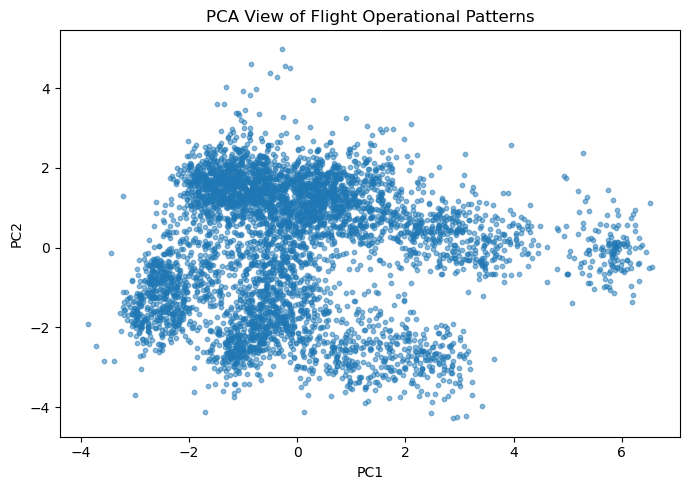

In [7]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance by PC1 and PC2:")
print(pca.explained_variance_ratio_.round(4))

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10, alpha=0.5)
plt.title("PCA View of Flight Operational Patterns")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## 6. DBSCAN eps check with nearest neighbors

DBSCAN groups points based on density. Two important parameters are:

- `eps`: the maximum distance for points to be considered neighbors
- `min_samples`: the number of nearby points needed to form a dense region

A k-distance plot can help choose a reasonable `eps`. I use the 5th nearest neighbor distance because I start with `min_samples = 5`.

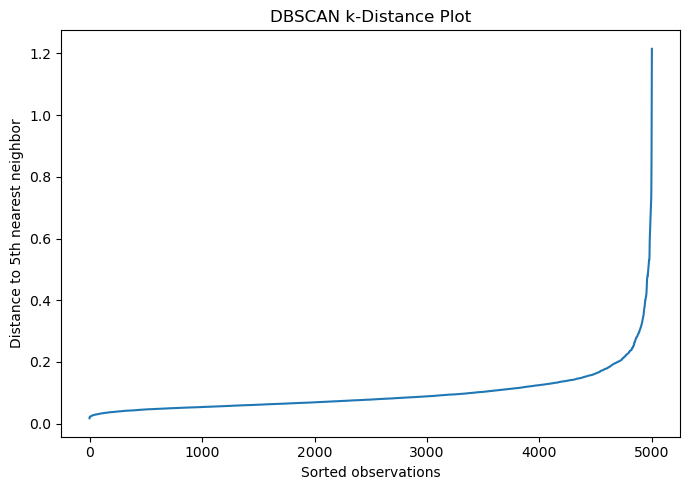

Suggested distance percentiles:
0.50    0.0782
0.75    0.1130
0.90    0.1627
0.95    0.2143
0.98    0.3115
dtype: float64


In [8]:
min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)

# Sort the distance to the kth nearest neighbor.
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(7, 5))
plt.plot(k_distances)
plt.title("DBSCAN k-Distance Plot")
plt.xlabel("Sorted observations")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.tight_layout()
plt.show()

print("Suggested distance percentiles:")
print(pd.Series(k_distances).quantile([0.50, 0.75, 0.90, 0.95, 0.98]).round(4))

## 7. Tune DBSCAN settings

I test several `eps` values based on the k-distance percentiles. The goal is not just to maximize a metric, but to find a reasonable clustering structure that does not label almost everything as noise or put almost everything into one cluster.

In [9]:
eps_values = [
    float(np.quantile(k_distances, 0.75)),
    float(np.quantile(k_distances, 0.90)),
    float(np.quantile(k_distances, 0.95)),
    float(np.quantile(k_distances, 0.98))
]

dbscan_rows = []

def safe_silhouette(X_values, labels):
    # Silhouette needs at least 2 clusters. Noise is labeled -1.
    non_noise = labels != -1
    unique_clusters = set(labels[non_noise])
    if non_noise.sum() < 10 or len(unique_clusters) < 2:
        return np.nan
    return silhouette_score(X_values[non_noise], labels[non_noise])

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_pca)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_rate = np.mean(labels == -1)
    score = safe_silhouette(X_pca, labels)

    dbscan_rows.append({
        "eps": eps,
        "min_samples": min_samples,
        "n_clusters": n_clusters,
        "noise_rate": noise_rate,
        "silhouette_no_noise": score
    })

dbscan_results = pd.DataFrame(dbscan_rows)
dbscan_results.round(4)

,eps,min_samples,n_clusters,noise_rate,silhouette_no_noise
0,0.1130,5,59,0.1570,-0.4055
1,0.1627,5,14,0.0626,-0.3316
2,0.2143,5,5,0.0266,-0.0812
3,0.3115,5,3,0.0116,0.4630


## 8. Fit selected DBSCAN model

I select a DBSCAN setting that creates more than one cluster while avoiding an extreme noise rate. DBSCAN is useful because it can identify observations that do not fit well into a dense group, which may represent unusual operating conditions.

In [10]:
valid_dbscan = dbscan_results[dbscan_results["n_clusters"] >= 2].copy()

if len(valid_dbscan) > 0:
    # Prefer higher silhouette score, but allow NaN handling.
    valid_dbscan["score_for_sort"] = valid_dbscan["silhouette_no_noise"].fillna(-999)
    selected = valid_dbscan.sort_values(["score_for_sort", "noise_rate"], ascending=[False, True]).iloc[0]
else:
    # Fallback if no setting creates multiple clusters.
    selected = dbscan_results.sort_values("noise_rate").iloc[0]

selected_eps = float(selected["eps"])
print("Selected eps:", round(selected_eps, 4))

final_dbscan = DBSCAN(eps=selected_eps, min_samples=min_samples)
dbscan_labels = final_dbscan.fit_predict(X_pca)

cluster_data = cluster_data.copy()
cluster_data["dbscan_cluster"] = dbscan_labels

print("DBSCAN cluster counts:")
print(cluster_data["dbscan_cluster"].value_counts().sort_index())

Selected eps: 0.3115
DBSCAN cluster counts:
dbscan_cluster
-1      58
 0    4803
 1     135
 2       4
Name: count, dtype: int64


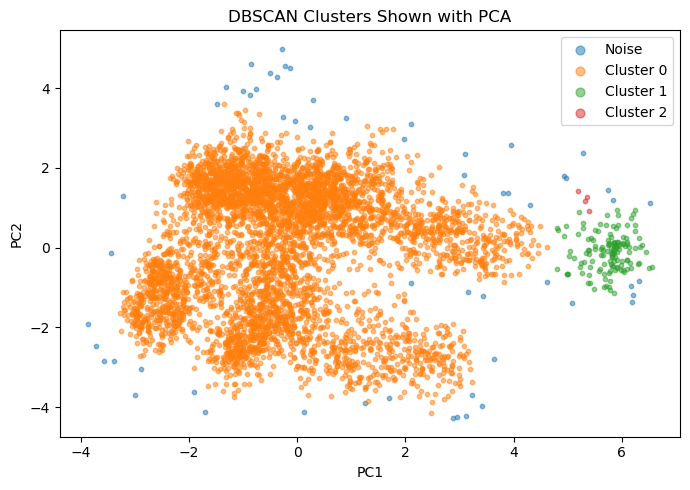

In [11]:
plt.figure(figsize=(7, 5))
for label in sorted(cluster_data["dbscan_cluster"].unique()):
    mask = cluster_data["dbscan_cluster"] == label
    label_name = "Noise" if label == -1 else f"Cluster {label}"
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.5, label=label_name)

plt.title("DBSCAN Clusters Shown with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(markerscale=2)
plt.tight_layout()
plt.show()

## 9. Interpret DBSCAN clusters using delay rate

After DBSCAN creates clusters, I compare each group by count and delay rate. Noise points are included as their own group labeled `-1`.

In [12]:
dbscan_summary = (
    cluster_data
    .groupby("dbscan_cluster")
    .agg(
        count=(target, "size"),
        delay_rate=(target, "mean"),
        avg_prcp=("PRCP", "mean") if "PRCP" in cluster_data.columns else (target, "mean"),
        avg_dep_airport_hist=("DEP_AIRPORT_HIST", "mean") if "DEP_AIRPORT_HIST" in cluster_data.columns else (target, "mean"),
        avg_dep_block_hist=("DEP_BLOCK_HIST", "mean") if "DEP_BLOCK_HIST" in cluster_data.columns else (target, "mean"),
        avg_carrier_hist=("CARRIER_HISTORICAL", "mean") if "CARRIER_HISTORICAL" in cluster_data.columns else (target, "mean")
    )
    .reset_index()
)

dbscan_summary["delay_rate_diff_from_overall"] = dbscan_summary["delay_rate"] - overall_delay_rate
dbscan_summary.round(4)

,dbscan_cluster,count,delay_rate,avg_prcp,avg_dep_airport_hist,avg_dep_block_hist,avg_carrier_hist,delay_rate_diff_from_overall
0,-1,58,0.1724,0.0634,0.1872,0.2150,0.1744,-0.0172
1,0,4803,0.1851,0.1048,0.1876,0.1888,0.1907,-0.0045
2,1,135,0.1407,0.0567,0.1837,0.2135,0.1465,-0.0489
3,2,4,0.0000,0.0025,0.1766,0.1299,0.1491,-0.1896


## 10. Hierarchical agglomerative clustering and linkage methods

Hierarchical agglomerative clustering starts with each point as its own cluster and then merges clusters step by step.

I compare these linkage methods:

- `ward`: merges clusters in a way that tries to minimize within-cluster variance
- `complete`: uses the farthest distance between points in clusters
- `average`: uses average distance between clusters
- `single`: uses the closest distance between clusters

Different linkage methods can produce different cluster structures.

In [13]:
hac_rows = []
linkage_methods = ["ward", "complete", "average", "single"]

# HAC can be slow, so use PCA representation for comparison.
for method in linkage_methods:
    hac = AgglomerativeClustering(n_clusters=4, linkage=method)
    labels = hac.fit_predict(X_pca)

    score = silhouette_score(X_pca, labels)
    hac_rows.append({
        "linkage": method,
        "n_clusters": 4,
        "silhouette_score": score
    })

hac_results = pd.DataFrame(hac_rows)
hac_results.sort_values("silhouette_score", ascending=False).round(4)

,linkage,n_clusters,silhouette_score
2,average,4,0.4487
0,ward,4,0.4315
1,complete,4,0.3391
3,single,4,0.1484


## 11. Fit selected HAC model

I select the linkage method with the best Silhouette score from the comparison above. I use four clusters as a readable starting point for interpretation.

In [14]:
best_linkage = hac_results.sort_values("silhouette_score", ascending=False).iloc[0]["linkage"]
print("Selected HAC linkage:", best_linkage)

final_hac = AgglomerativeClustering(n_clusters=4, linkage=best_linkage)
hac_labels = final_hac.fit_predict(X_pca)

cluster_data["hac_cluster"] = hac_labels

print("HAC cluster counts:")
print(cluster_data["hac_cluster"].value_counts().sort_index())

Selected HAC linkage: average
HAC cluster counts:
hac_cluster
0     588
1    2382
2     441
3    1589
Name: count, dtype: int64


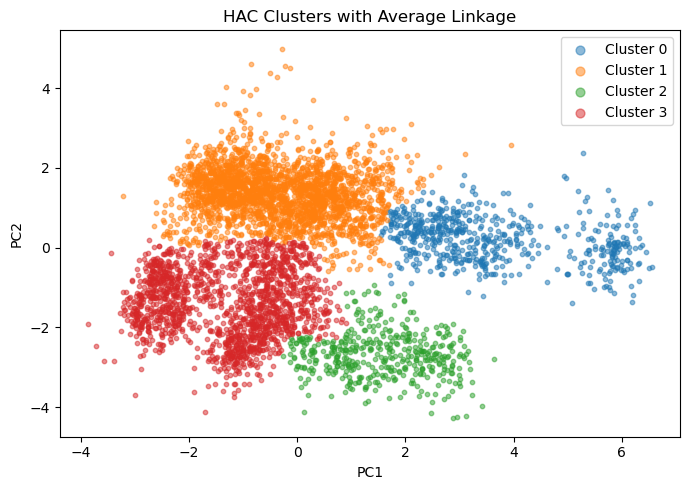

In [15]:
plt.figure(figsize=(7, 5))
for label in sorted(cluster_data["hac_cluster"].unique()):
    mask = cluster_data["hac_cluster"] == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.5, label=f"Cluster {label}")

plt.title(f"HAC Clusters with {best_linkage.title()} Linkage")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(markerscale=2)
plt.tight_layout()
plt.show()

## 12. HAC cluster interpretation

I compare HAC clusters by delay rate and selected operational averages. This helps show whether the hierarchical clusters are meaningful for the airline delay project.

In [16]:
hac_summary = (
    cluster_data
    .groupby("hac_cluster")
    .agg(
        count=(target, "size"),
        delay_rate=(target, "mean"),
        avg_prcp=("PRCP", "mean") if "PRCP" in cluster_data.columns else (target, "mean"),
        avg_dep_airport_hist=("DEP_AIRPORT_HIST", "mean") if "DEP_AIRPORT_HIST" in cluster_data.columns else (target, "mean"),
        avg_dep_block_hist=("DEP_BLOCK_HIST", "mean") if "DEP_BLOCK_HIST" in cluster_data.columns else (target, "mean"),
        avg_carrier_hist=("CARRIER_HISTORICAL", "mean") if "CARRIER_HISTORICAL" in cluster_data.columns else (target, "mean")
    )
    .reset_index()
)

hac_summary["delay_rate_diff_from_overall"] = hac_summary["delay_rate"] - overall_delay_rate
hac_summary.round(4)

,hac_cluster,count,delay_rate,avg_prcp,avg_dep_airport_hist,avg_dep_block_hist,avg_carrier_hist,delay_rate_diff_from_overall
0,0,588,0.2092,0.0741,0.1842,0.2034,0.1828,0.0196
1,1,2382,0.1767,0.0997,0.1896,0.1818,0.1910,-0.0129
2,2,441,0.1950,0.0989,0.1808,0.2058,0.1845,0.0054
3,3,1589,0.1812,0.1195,0.1874,0.1922,0.1905,-0.0084


## 13. Dendrogram

A dendrogram shows how observations merge together in hierarchical clustering. I use a small sample because dendrograms become unreadable with thousands of observations.

This plot helps show the nested structure of the data and where a cut could be made to form clusters.

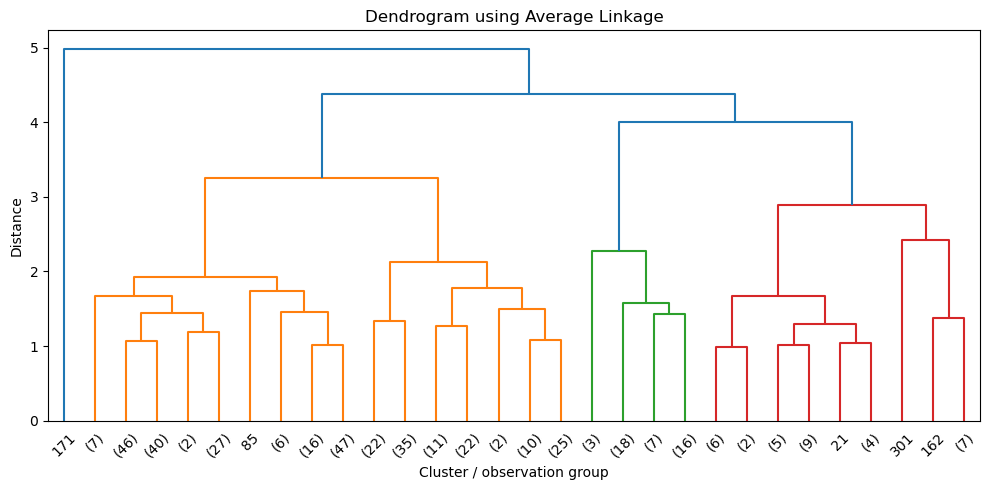

In [17]:
dendro_idx = np.random.RandomState(RANDOM_STATE).choice(
    X_pca.shape[0],
    size=min(DENDROGRAM_SAMPLE_SIZE, X_pca.shape[0]),
    replace=False
)

X_dendro = X_pca[dendro_idx]

linked = linkage(X_dendro, method=best_linkage if best_linkage != "ward" else "ward")

plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode="lastp", p=30, leaf_rotation=45, leaf_font_size=10)
plt.title(f"Dendrogram using {best_linkage.title()} Linkage")
plt.xlabel("Cluster / observation group")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

## Week 11 conclusion

DBSCAN and HAC were useful because they looked at the airline delay data differently than supervised classification models. DBSCAN looked for dense groups and also labeled some points as noise. This was useful because unusual flights or operating conditions may not fit into a normal cluster. The main challenge was choosing `eps`, because small changes in `eps` can change the number of clusters and the amount of noise.

Hierarchical agglomerative clustering was useful because it showed how observations merge into larger groups. The linkage comparison showed that different definitions of cluster distance can lead to different results. The dendrogram helped visualize this process, although it had to be created on a smaller sample to stay readable.

For the capstone project, these clustering methods helped support the idea that flight delay risk is connected to operating conditions and system patterns. The clusters were not meant to replace the predictive models, but they gave another way to explore whether flights naturally group by weather, airport history, carrier history, and delay-related stress.

The main limitation is that clustering results can be sensitive to scaling, feature choice, sample size, and distance settings. Because of that, I would use these results as exploratory evidence rather than as the main final model.